# 🔮 Step 4: Prediction & Analysis

Use the trained model to classify new images and calculate areas.

## What This Notebook Does:
- ✅ Load trained CNN model
- ✅ Load new/test satellite images
- ✅ Make predictions
- ✅ Visualize results
- ✅ Calculate area changes (km²)

---

**Previous:** [03_model_training.ipynb](03_model_training.ipynb)  
**Next:** [05_visualization_reports.ipynb](05_visualization_reports.ipynb)

## Load Model and Data

In [1]:
# Cell: Load Model and Data

import rasterio
import numpy as np
import joblib
import json
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler

# Load trained model
print("📂 Loading trained model...")
model = joblib.load("outputs/coastal_classifier_model.pkl")
scaler = joblib.load("outputs/feature_scaler.pkl")

# Load metadata
print("📂 Loading metadata...")
with open("outputs/model_metadata.json") as f:
    metadata = json.load(f)

# Use 'classes' instead of 'class_names'
class_names = {i: str(name) for i, name in enumerate(metadata['classes'])}

print(f"✅ Model loaded!")
print(f"   Test Accuracy: {metadata['test_accuracy']*100:.2f}%")
print(f"   Classes: {list(class_names.values())}")

📂 Loading trained model...
📂 Loading metadata...
✅ Model loaded!
   Test Accuracy: 87.61%
   Classes: ['1', '2', '3', '4', '5']


## Load New Images for Prediction

*For this demo, using the same images. In production, load different year's data.*

In [2]:
# Load bands (for demo, using same images - replace with new year's data)
print("📂 Loading images...")
new_B02 = rasterio.open("coastalImage/B02.tiff").read(1).astype(float)
new_B03 = rasterio.open("coastalImage/B03.tiff").read(1).astype(float)
new_B04 = rasterio.open("coastalImage/B04.tiff").read(1).astype(float)
new_B08 = rasterio.open("coastalImage/B08.tiff").read(1).astype(float)

# Calculate NDVI
new_ndvi = (new_B08 - new_B04) / (new_B08 + new_B04 + 1e-10)

# Store shape for reshaping
original_shape = new_B02.shape

# Flatten and prepare
new_data = np.stack([
    new_B02.flatten(),
    new_B03.flatten(),
    new_B04.flatten(),
    new_B08.flatten(),
    new_ndvi.flatten()
], axis=1)

new_X = new_data.reshape(-1, 5, 1)

print(f"✅ Images loaded!")
print(f"   Shape: {original_shape}")
print(f"   Pixels: {new_X.shape[0]:,}")

📂 Loading images...
✅ Images loaded!
   Shape: (424, 480)
   Pixels: 203,520


## Make Predictions and Reshape

In [3]:
# Cell: Make Predictions and Reshape

# Load the processed image with all 7 bands
print("📂 Loading processed image...")
with rasterio.open("processed_image_with_indices.tif") as src:
    image_data = src.read()
    profile = src.profile.copy()

print(f"Making predictions on processed image...")
print(f"Image shape: {image_data.shape}")

# Identify nodata pixels BEFORE prediction
bands, height, width = image_data.shape
nodata_mask = np.all(image_data == 0, axis=0) | np.any(np.isnan(image_data), axis=0)

print(f"Nodata pixels detected: {np.sum(nodata_mask):,}")

# Reshape: (7, H, W) -> (H*W, 7)
reshaped_img = image_data.reshape(bands, -1).T 

# Handle NaNs
reshaped_img = np.nan_to_num(reshaped_img, nan=0)

# Scale using the saved scaler
reshaped_img_scaled = scaler.transform(reshaped_img)

# Predict!
print("🔮 Making predictions... (this may take a minute)")
prediction_flat = model.predict(reshaped_img_scaled)

# Add this after prediction_flat = model.predict(reshaped_img_scaled)

prediction_flat_filtered = prediction_flat.copy()
prediction_flat = prediction_flat_filtered
# Set nodata pixels to 0 AFTER prediction
prediction_flat[nodata_mask.flatten()] = 0

# Reshape back to map: (H*W) -> (H, W)
prediction_map = prediction_flat.reshape(height, width)


print(f"✅ Predictions complete!")
print(f"   Predicted classes (excluding nodata): {np.unique(prediction_flat[prediction_flat > 0])}")

📂 Loading processed image...
Making predictions on processed image...
Image shape: (7, 424, 480)
Nodata pixels detected: 0
🔮 Making predictions... (this may take a minute)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s


✅ Predictions complete!
   Predicted classes (excluding nodata): [1 2 3 4 5]


[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


In [4]:
# Quick diagnostic - run this between prediction and save cells
print("prediction_flat" in dir())
print("prediction_map" in dir())
try:
    print(f"prediction_flat shape: {prediction_flat.shape}")
    print(f"prediction_map shape: {prediction_map.shape}")
except NameError as e:
    print(f"Missing variable: {e}")

True
True
prediction_flat shape: (203520,)
prediction_map shape: (424, 480)


## Save and Visualize

🧹 Applying majority filter to clean noise...
✅ Noise cleaning complete!
✅ Map saved as 'final_classification_map.tif'


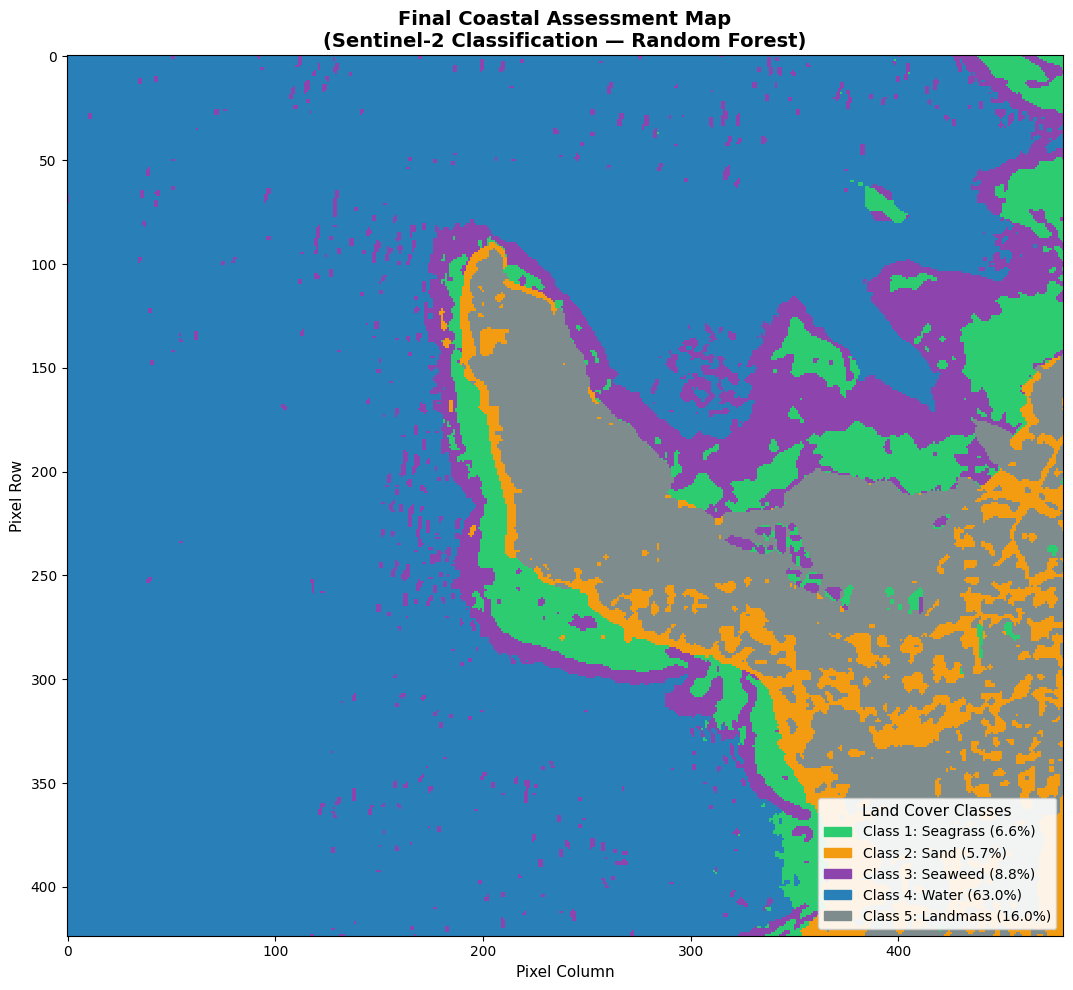


📋 Classification Summary:
Class  Name             Pixels    Area (ha)   Coverage
-------------------------------------------------------
1      Seagrass         13,466       134.66       6.6%
2      Sand             11,585       115.85       5.7%
3      Seaweed          17,810       178.10       8.8%
4      Water           128,177      1281.77      63.0%
5      Landmass         32,482       324.82      16.0%
-------------------------------------------------------
Total                  203,520      2035.20     100.0%

💾 High-res map saved to 'outputs/final_classification_map.png'


In [5]:
# Cell: Save and Visualize (IMPROVED)

import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.ndimage import generic_filter
from statistics import mode

# ---------------------------------------------------------------
# CLASS DEFINITIONS - adjust names/colors to match your classes
# ---------------------------------------------------------------
CLASS_INFO = {
    1: {"name": "Seagrass",  "color": "#2ecc71"},  # green
    2: {"name": "Sand",      "color": "#f39c12"},  # orange
    3: {"name": "Seaweed",   "color": "#8e44ad"},  # purple
    4: {"name": "Water",     "color": "#2980b9"},  # blue
    5: {"name": "Landmass",  "color": "#7f8c8d"},  # grey
}

# ---------------------------------------------------------------
# STEP 1: MAJORITY FILTER - clean salt-and-pepper noise
# ---------------------------------------------------------------
print("🧹 Applying majority filter to clean noise...")

def majority(values):
    """Return the most common value in a neighborhood window."""
    vals = values[values > 0]  # ignore nodata (0)
    if len(vals) == 0:
        return 0
    counts = np.bincount(vals.astype(int))
    return np.argmax(counts)

# Apply 3x3 majority filter
prediction_map_clean = generic_filter(
    prediction_map.astype(float),
    majority,
    size=3
).astype(np.uint8)

print("✅ Noise cleaning complete!")

# ---------------------------------------------------------------
# STEP 2: SAVE GEOTIFF with proper metadata
# ---------------------------------------------------------------
with rasterio.open("processed_image_with_indices.tif") as src:
    profile = src.profile.copy()

profile.update(count=1, dtype=rasterio.uint8, nodata=0)

with rasterio.open("final_classification_map.tif", 'w', **profile) as dst:
    dst.write(prediction_map_clean, 1)

print("✅ Map saved as 'final_classification_map.tif'")

# ---------------------------------------------------------------
# STEP 3: BUILD COLORMAP from CLASS_INFO
# ---------------------------------------------------------------
# Get all unique predicted classes (excluding nodata=0)
unique_classes = sorted([c for c in np.unique(prediction_map_clean) if c > 0])

# Remap class IDs to sequential colormap indices
# prediction_map_clean contains raw class IDs (1,2,3,4,5)
# We'll display directly using a full colormap indexed by class ID
max_class = max(CLASS_INFO.keys())
colors = ['#ffffff']  # index 0 = nodata = white
for i in range(1, max_class + 1):
    if i in CLASS_INFO:
        colors.append(CLASS_INFO[i]["color"])
    else:
        colors.append('#ffffff')

cmap = ListedColormap(colors)

# ---------------------------------------------------------------
# STEP 4: VISUALIZE with labeled legend
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(
    prediction_map_clean,
    cmap=cmap,
    vmin=0,
    vmax=max_class,
    interpolation='nearest'
)

# Build a proper legend with class names
legend_patches = []
for cls_id in unique_classes:
    if cls_id in CLASS_INFO:
        info = CLASS_INFO[cls_id]
        pixel_count = np.sum(prediction_map_clean == cls_id)
        total_valid = np.sum(prediction_map_clean > 0)
        pct = (pixel_count / total_valid) * 100
        label = f"Class {cls_id}: {info['name']} ({pct:.1f}%)"
        patch = mpatches.Patch(color=info['color'], label=label)
        legend_patches.append(patch)

ax.legend(
    handles=legend_patches,
    loc='lower right',
    fontsize=10,
    framealpha=0.9,
    title="Land Cover Classes",
    title_fontsize=11
)

ax.set_title("Final Coastal Assessment Map\n(Sentinel-2 Classification — Random Forest)", 
             fontsize=14, fontweight='bold')
ax.set_xlabel("Pixel Column", fontsize=11)
ax.set_ylabel("Pixel Row", fontsize=11)
plt.tight_layout()

plt.savefig("outputs/final_classification_map.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------
# STEP 5: PRINT SUMMARY
# ---------------------------------------------------------------
print("\n📋 Classification Summary:")
print(f"{'Class':<6} {'Name':<12} {'Pixels':>10} {'Area (ha)':>12} {'Coverage':>10}")
print("-" * 55)

pixel_size_m = 10
area_per_pixel_ha = (pixel_size_m ** 2) / 10000

total_valid = np.sum(prediction_map_clean > 0)
for cls_id in sorted(unique_classes):
    if cls_id in CLASS_INFO:
        count = np.sum(prediction_map_clean == cls_id)
        area_ha = count * area_per_pixel_ha
        pct = (count / total_valid) * 100
        name = CLASS_INFO[cls_id]['name']
        print(f"{cls_id:<6} {name:<12} {count:>10,} {area_ha:>12.2f} {pct:>9.1f}%")

print("-" * 55)
print(f"{'Total':<6} {'':<12} {total_valid:>10,} {total_valid * area_per_pixel_ha:>12.2f} {'100.0%':>10}")
print("\n💾 High-res map saved to 'outputs/final_classification_map.png'")



## Calculate Area by Class

In [6]:
# Cell: Calculate Area by Class

import pandas as pd

# 1. Define Pixel Size for Sentinel-2
pixel_size_meters = 10
area_per_pixel_sqm = pixel_size_meters * pixel_size_meters  # 100 m²

# 2. Count the pixels for each class
# 'prediction_flat' comes from the model.predict() step in the previous cell
unique_labels, counts = np.unique(prediction_flat, return_counts=True)

# 3. Create a Summary Table
results = []

for label, count in zip(unique_labels, counts):
    area_sqm = count * area_per_pixel_sqm
    area_hectares = area_sqm / 10000       # 10,000 m² = 1 Hectare
    area_sqkm = area_sqm / 1e6             # 1,000,000 m² = 1 km²
    
    results.append({
        "Class Name": label,
        "Pixel Count": count,
        "Area (m²)": f"{area_sqm:,.0f}",
        "Area (Hectares)": f"{area_hectares:,.2f}",
        "Area (km²)": f"{area_sqkm:,.4f}"
    })

# 4. Display as a clean DataFrame
area_df = pd.DataFrame(results)
print("--- 📊 Coastal Assessment Area Report ---")
print(area_df.to_string(index=False))

# Optional: Save report to CSV
area_df.to_csv("final_area_report.csv", index=False)

print("\n💾 Results saved to 'final_area_report.csv'")
print("\n" + "="*60)
print("✅ PREDICTION & ANALYSIS COMPLETE!")
print("="*60)
print("\n📌 Next Step: Open 05_visualization_reports.ipynb for multi-year trends")

--- 📊 Coastal Assessment Area Report ---
 Class Name  Pixel Count  Area (m²) Area (Hectares) Area (km²)
          1        13782  1,378,200          137.82     1.3782
          2        12300  1,230,000          123.00     1.2300
          3        22660  2,266,000          226.60     2.2660
          4       123124 12,312,400        1,231.24    12.3124
          5        31654  3,165,400          316.54     3.1654

💾 Results saved to 'final_area_report.csv'

✅ PREDICTION & ANALYSIS COMPLETE!

📌 Next Step: Open 05_visualization_reports.ipynb for multi-year trends
